# Chapter 14: Building a World Inside

A planner evaluates tomorrow through an approximate transition model. Small one-step errors can matter more when the controller looks farther ahead. Yet a large worst-case bound does not mean the actual planning error reached it. Both quantities deserve separate places in the report.

This notebook compares two finite kernels under one fixed policy and one common immediate reward vector. It computes their transition mismatch, propagates finite-horizon values, and plots actual value error beside the chapter's conditional horizon bound. The changed case lengthens the horizon without changing the model. The transfer case makes the kernels identical, giving an exact zero-error check before any more complicated interpretation.

**Outcome:** Calculate uniform transition error, actual fixed-policy finite values, and conditional bounds.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later and the packages in `requirements.txt` at the top of the repository. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For each state, total variation between the true and modeled transition rows is half the sum of absolute probability differences. Uniform error epsilon is the maximum of those row distances. An average row error cannot replace that maximum in a uniform bound.

With common expected immediate rewards in [0,R], one fixed policy, and discount gamma<1, the chapter's discounted value bound is gamma epsilon R/(1-gamma)^2. This quantity applies under those prerequisites; it is not an estimate fitted to the finite error curve. Reward-model mismatch would need another term.

For H rewards and zero terminal continuation, the undiscounted finite-horizon bound is R epsilon H(H-1)/2. It also bounds the discounted finite calculation because discounting can only reduce these nonnegative error contributions. The implementation computes V_h=r+gamma P V_(h-1) and modeled W_h=r+gamma Q W_(h-1), starting both at zero, then records max_s |V_h(s)-W_h(s)|.

The kernels already absorb a fixed policy. A state-value bound alone does not provide the uniform action-value error and action gap needed to certify a choice ranking. Keep that missing prerequisite explicit.

## A calculation you can run

Provide two aligned square probability matrices and one nonnegative reward vector. Every row must sum to one. Declare discount and horizon. The function computes the uniform total-variation error, maximum reward, both finite value recurrences, the actual maximum error at each horizon, and the two conditional bounds.

Figures use reward horizon on the horizontal axis and reward units on the vertical axis. Plotting bound and actual error separately avoids disguising a small error beneath a large envelope. In the changed case increase horizon from five to twenty and predict how the quadratic envelope changes. Inspect the actual curve independently; it need not grow at the same rate. Export common-reward and fixed-policy assumptions with the numerical result.

The next cell finds the repository root and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file() and (p / "src" / "math_ai_agents").is_dir()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from a clone of the math-ai-agents repository.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 14
inputs = {'true_transition': [[0.9, 0.1], [0.2, 0.8]],
 'model_transition': [[0.88, 0.12], [0.22, 0.78]],
 'rewards': [0, 1],
 'discount': 0.9,
 'horizon': 5}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 14: transition-model-bound
How much value error can this approximate world model introduce?
Evidence: constructed teaching example

Calculated quantities:
{
  "uniform_tv_error": 0.02,
  "true_values": [
    0.55354113,
    2.98801774
  ],
  "model_values": [
    0.6403010023,
    2.921214829
  ],
  "max_finite_value_error": 0.08675987227,
  "discounted_infinite_bound": 1.8,
  "finite_horizon_bound": 0.2
}

Interpretation:
Both kernels share the same immediate reward vector under one fixed policy. The uniform total-variation error controls the conditional bound; the actual finite error can be much smaller.

Assumptions:
- Fixed policy absorbed into each transition matrix.
- Common expected immediate reward in [0,R].
- Finite calculation has zero terminal continuation; discounted bound assumes gamma below one.

Limitations:
- A bound is not a measured planning error.
- This state-value bound alone does not certify an action ranking.
- Reward-model error would require an addition

Both default row distances are 0.02, so epsilon=0.02. With R=1 and gamma=0.9, the discounted infinite bound is 1.8. At horizon 5 the finite bound is 0.02(5)(4)/2=0.2. The actual finite error is calculated from the two recurrences and must remain below the finite envelope.

At horizon 20 the finite bound grows to 3.8, even though each transition row changed by the same amount. That growth is a sensitivity statement under a worst-case construction. It does not say that the actual error became 3.8, and it does not establish that any particular action ranking reversed.

Two bounds are reported and both are valid. At horizon 20 the finite-horizon bound (3.8) is the looser one and the discounted infinite-horizon bound (1.8) the tighter, so the tightest valid statement is their minimum. The finite bound is not a stronger warning.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

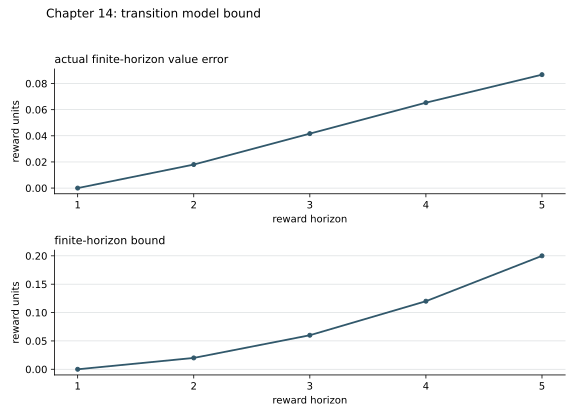

In [3]:
display(SVG(figure_svg(report)))

**Figure 14.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A common misuse inserts average model error into a uniform bound. A model may be accurate on frequently observed states and badly wrong at the one state that changes the plan. The maximum row distance protects the stated domain, while an average describes a different estimand.

Another misuse compares reward functions that differ and then attributes all value error to transition mismatch. This input contract intentionally supplies only one common reward vector. If the model invents immediate reward, the implementation's bound assumptions no longer apply.

Finally, an error bound is not a decision certificate. Even a small value bound can overwhelm a smaller action gap, and this fixed-policy state calculation does not inspect alternative actions. Use it to audit model sensitivity, then state the extra action-value and gap information required for ranking guarantees.

Chapter 14: transition-model-bound
How much value error can this approximate world model introduce?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "uniform_tv_error": 0.02,
  "true_values": [
    2.027264312,
    4.729704829
  ],
  "model_values": [
    2.231030443,
    4.694010975
  ],
  "max_finite_value_error": 0.2037661306,
  "discounted_infinite_bound": 1.8,
  "finite_horizon_bound": 3.8
}

Interpretation:
Both kernels share the same immediate reward vector under one fixed policy. The uniform total-variation error controls the conditional bound; the actual finite error can be much smaller.

Assumptions:
- Fixed policy absorbed into each transition matrix.
- Common expected immediate reward in [0,R].
- Finite calculation has zero terminal continuation; discounted bound assumes gamma below one.

Limitations:
- A bound is not a measured planning error.
- This state-value bound alone does not certify an action ranking.
- Reward-model error would require a

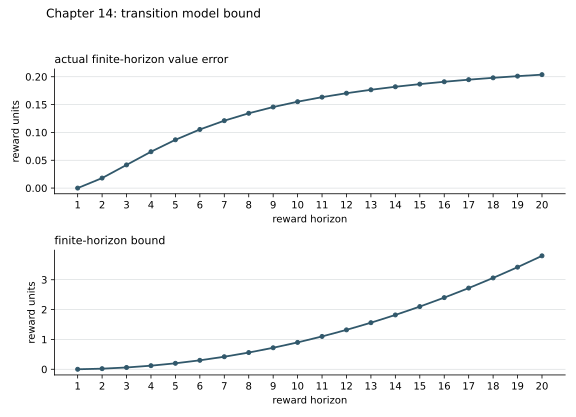

In [4]:
changed_inputs = {'true_transition': [[0.9, 0.1], [0.2, 0.8]],
 'model_transition': [[0.88, 0.12], [0.22, 0.78]],
 'rewards': [0, 1],
 'discount': 0.9,
 'horizon': 20}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 14.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer kernels are identical. Epsilon is zero, finite values agree at every stage, and both bounds are zero. This identity is a useful check of matrix alignment and recurrence behavior. If an implementation returned nonzero error here, investigate the computation before interpreting a more realistic model.

For reader data, explain how the true kernel was measured or constructed. Usually a deployed world does not provide exact transition probabilities. In that case the calculated epsilon is conditional on estimates and their support, not a known universal error. Preserve uncertainty or specify the measurements needed to bound it on the relevant policy domain.

In [5]:
transfer_inputs = {'true_transition': [[1, 0], [0, 1]],
 'model_transition': [[1, 0], [0, 1]],
 'rewards': [1, 2],
 'discount': 0.5,
 'horizon': 4}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 14: transition-model-bound
How much value error can this approximate world model introduce?
Evidence: constructed transfer example

Calculated quantities:
{
  "uniform_tv_error": 0.0,
  "true_values": [
    1.875,
    3.75
  ],
  "model_values": [
    1.875,
    3.75
  ],
  "max_finite_value_error": 0.0,
  "discounted_infinite_bound": 0.0,
  "finite_horizon_bound": 0.0
}

Interpretation:
Both kernels share the same immediate reward vector under one fixed policy. The uniform total-variation error controls the conditional bound; the actual finite error can be much smaller.

Assumptions:
- Fixed policy absorbed into each transition matrix.
- Common expected immediate reward in [0,R].
- Finite calculation has zero terminal continuation; discounted bound assumes gamma below one.

Limitations:
- A bound is not a measured planning error.
- This state-value bound alone does not certify an action ranking.
- Reward-model error would require an additional term.

Execution: completed local

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **true_transition:** Square row-stochastic true kernel after fixing a policy.
- **model_transition:** Same-size approximate row-stochastic kernel for that policy.
- **rewards:** Common immediate state reward vector, finite and nonnegative.
- **discount:** Gamma in [0,0.9999].
- **horizon:** Integer reward horizon 1..1000 with zero terminal continuation.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch14.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 14: transition-model-bound
How much value error can this approximate world model introduce?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "uniform_tv_error": 0.0,
  "true_values": [
    1.875,
    3.75
  ],
  "model_values": [
    1.875,
    3.75
  ],
  "max_finite_value_error": 0.0,
  "discounted_infinite_bound": 0.0,
  "finite_horizon_bound": 0.0
}

Interpretation:
Both kernels share the same immediate reward vector under one fixed policy. The uniform total-variation error controls the conditional bound; the actual finite error can be much smaller.

Assumptions:
- Fixed policy absorbed into each transition matrix.
- Common expected immediate reward in [0,R].
- Finite calculation has zero terminal continuation; discounted bound assumes gamma below one.

Limitations:
- A bound is not a measured planning error.
- This state-value bound alone does not certify an action ranking.
- Reward-model error would require an additional t

## Questions

1. Compute default epsilon.

2. Compute horizon 20 finite bound.

3. What if the reward model also differs?

Answers: [separate solutions](../solutions/ch14.md). Try the calculation before opening them.

## Summary

Transition models accumulate errors through future value. Uniform total variation, common immediate rewards, and a fixed policy are essential to the implemented bounds. The notebook separates actual finite error from conditional envelopes and checks the identical-kernel case. Extending horizon changes sensitivity without changing one-step mismatch. A bound is neither a measured planning error nor an action-ranking certificate; report its prerequisites and the evidence supporting the supplied kernels.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The matching skill is [`skills/14-transition-model-bound`](../skills/14-transition-model-bound/). It uses this notebook's computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 14.1

![Equation 14.1](../assets/math/52b47c925ae699342ab3.svg)

Equation (14.1) measures how wrong the model is about a single step, at its worst state and action.

For each state and action, add up how much the two distributions disagree, halve it, and take the largest such disagreement anywhere.

LaTeX source, preserved for inspection:

```latex
\epsilon \;=\; \max_{x,a}\; \tfrac{1}{2}\sum_{x'}\big|\hat P(x'\mid x,a) - P(x'\mid x,a)\big|.
\tag{14.1}
```

### Equation 14.2

![Equation 14.2](../assets/math/b20fc29975e836ddc4c8.svg)

Equation (14.2) bounds how far the value computed inside the model can sit from the value in the world.

Multiply the one-step error by the discount factor and largest reward, then divide by the square of one minus the discount factor.

LaTeX source, preserved for inspection:

```latex
\big|\hat V^{\pi}(x) - V^{\pi}(x)\big| \;\le\; \frac{\gamma\,\epsilon\,R}{(1-\gamma)^2}.
\tag{14.2}
```

### Equation 14.3

![Equation 14.3](../assets/math/02d58a83dac048591dea.svg)

Equation (14.3) measures how much better the best action at a state is than the runner-up.

Subtract the value of the second best action from the value of the best one.

LaTeX source, preserved for inspection:

```latex
\Delta(x) \;=\; \max_{a}Q^{\pi}(x,a) \;-\; \max_{a \neq a^{*}}Q^{\pi}(x,a).
\tag{14.3}
```

### Equation 14.4

![Equation 14.4](../assets/math/b90bd3f384ebe300fc72.svg)

Equation (14.4) gives the largest positive integer horizon certified to preserve a unique action ranking under the stated finite-model assumptions.

Within the declared planning cap `H_{\max}`, find the largest positive integer horizon at which twice the finite-horizon action-value error still fits inside the action gap.

LaTeX source, preserved for inspection:

```latex
H^{*} \;=\; \max\Big\{ H \in \mathbb{Z}_{>0} \;:\; H \leq H_{\max},\;
R\,\epsilon\,H(H-1) \;<\; \Delta \Big\}.
\tag{14.4}
```